In [27]:
import os
import cv2
import tensorflow as tf  
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils import show_img, split_into_char_images, preprocessing_remove_lines,  preprocessing_split_by_characters

In [19]:
chars_train_dir = "clean_train_data/"

In [20]:
# Load training data
def load_dir_pngs_and_preprocess(directory):
    labels = []
    imgs = []
    for (root,dirs,files) in os.walk(directory, topdown=True):
        for file in tqdm(files, desc=f"Loading pngs from '{directory}'"):
            if not file.endswith('.png'):
                continue
            label = file.split("_")[0]
            img_path = os.path.join(root, file)
            labels.append(label)
            imgs.append(cv2.imread(img_path))
    return labels, imgs


In [21]:
labels, imgs = load_dir_pngs_and_preprocess(chars_train_dir)

Loading pngs from 'clean_train_data/': 100%|████████████████████████████████████| 16002/16002 [00:05<00:00, 2852.62it/s]


In [63]:
def process_character_images(imgs):
    min_scale = 1000
    processed = imgs
    for i, img in enumerate(imgs):
        # --- Convert to grayscale ---
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # --- Invert so character = white (255), background = black (0) ---
        gray = 255 - gray
        
        # --- Find bounding box of character ---
        coords = cv2.findNonZero(gray)
        x, y, w, h = cv2.boundingRect(coords)
        
        # --- Crop + 3px padding ---
        pad = 3
        x1 = max(x - pad, 0)
        y1 = max(y - pad, 0)
        x2 = min(x + w + pad, gray.shape[1])
        y2 = min(y + h + pad, gray.shape[0])
        cropped = gray[y1:y2, x1:x2]
    
        # --- Normalize brightness: stretch intensity range to full 0–255 ---
        min_val, max_val = np.min(cropped), np.max(cropped)
        if max_val > min_val:  # avoid divide-by-zero if image is uniform
            cropped = (cropped - min_val) * (255.0 / (max_val - min_val))
            cropped = np.clip(cropped, 0, 255).astype(np.uint8)
        
        # --- Target canvas and padding ---
        target_size = 42
        pad = 3
        available_size = target_size - 2 * pad  # 38×38 drawable area
    
        h, w = cropped.shape
        scale = min(available_size / h, available_size / w)  # scale to fit within 38×38
        min_scale = scale if scale < min_scale else min_scale
        processed[i] = cropped

    scale = min_scale
    for i, cropped in enumerate(processed):
        h, w = cropped.shape
        # --- Resize with preserved aspect ratio ---
        new_w, new_h = int(w * scale), int(h * scale)
        resized = cv2.resize(cropped, (new_w, new_h), interpolation=cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC)
    
        # --- Create blank 42×42 black background ---
        canvas = np.zeros((target_size, target_size), dtype=np.uint8)
        
        # --- Center the character ---
        y_offset = (target_size - new_h) // 2
        x_offset = (target_size - new_w) // 2
        canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized
        processed[i] = canvas
    return processed

In [64]:
def split_into_char_images(img):
    img = preprocessing_remove_lines(img) # Remove lines
    _, char_images = preprocessing_split_by_characters(img) # Split chars
    return char_images

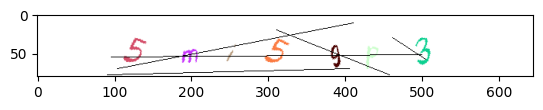

In [71]:
img = imgs[9]
show_img(img)

(80, 645, 3)


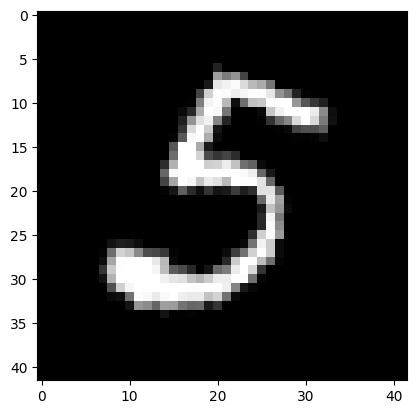

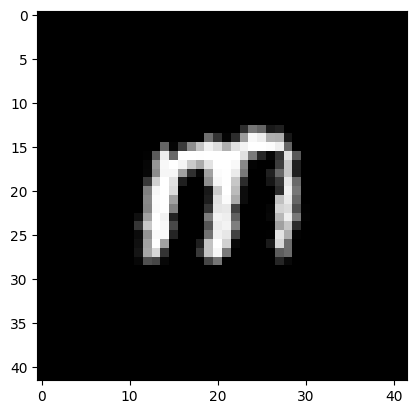

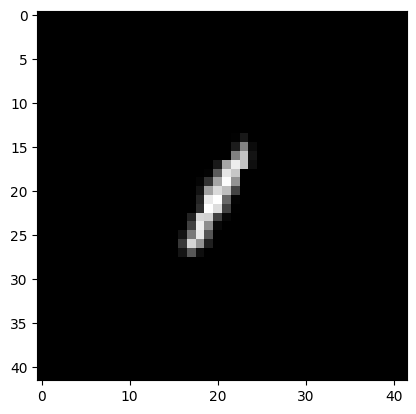

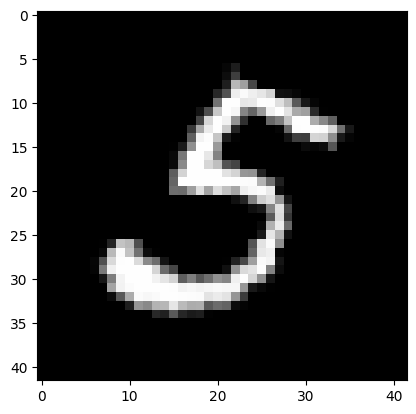

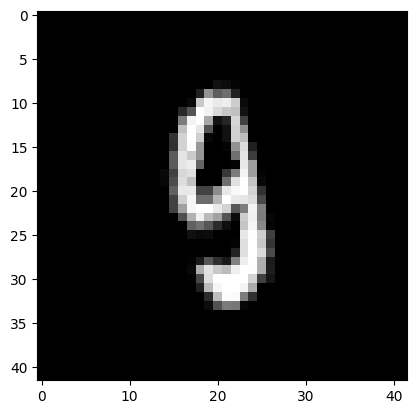

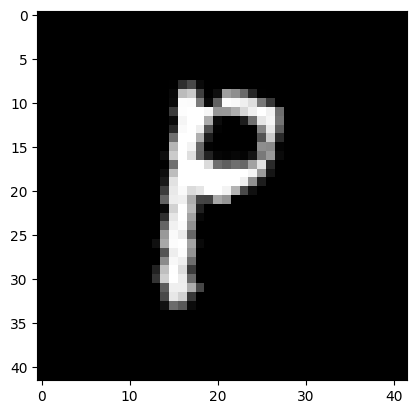

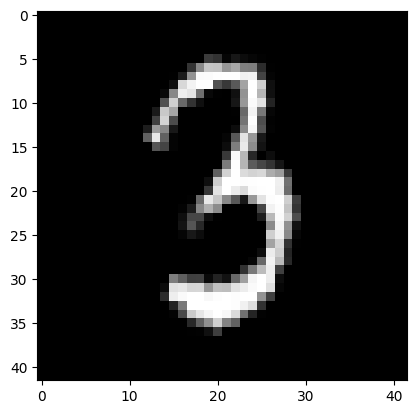

In [72]:
char_imgs = split_into_char_images(img)
print(char_imgs[0].shape)
for img in process_character_images(char_imgs):
    show_img(img)